In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv('telco_customer_churn_cleaned.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget Distribution:")
print(df['churn_flag'].value_counts())
print(f"\nChurn Rate: {df['churn_flag'].mean() * 100:.1f}%")

Shape: 7043 rows × 31 columns

Target Distribution:
churn_flag
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.5%




### What signals indicate a customer is about to churn?
- Short tenure (new customers, no habit formed)
- Month-to-month contract (no commitment, can leave anytime)
- Few services (low integration, easy to switch)
- Manual payment method (friction, monthly decision point)
- High monthly charges relative to services (value perception issue)

### What signals indicate a customer is valuable long-term?
- High total charges (already invested significantly)
- Multiple services (deeply integrated into daily life)
- Long tenure (proven loyalty)
- Automatic payment (frictionless, set-it-forget-it)
- Contract commitment (1-2 year agreements)

### What signals indicate engagement or loyalty?
- Multiple addon services (security, backup, streaming)
- Long tenure (survived multiple evaluation periods)
- Contract renewals (chose to stay)
- Low friction billing (paperless + automatic payment)

---

###FEATURE CATEGORIES

### Category 1: RECENCY-LIKE SIGNALS
**Why:** New customers churn faster; long-term customers have inertia  
**Planned:** tenure buckets (0-6mo/6-24mo/24mo+), trial period flag

### Category 2: FREQUENCY/ENGAGEMENT SIGNALS
**Why:** More services = higher switching costs and daily value  
**Planned:** total service count, engagement tier, phone-only risk flag

### Category 3: MONETARY VALUE SIGNALS
**Why:** Revenue quality matters more than raw revenue  
**Planned:** average revenue per month (ARPM), spending tier, efficiency ratio

### Category 4: CONTRACT RISK SIGNALS
**Why:** Contracts create lock-in; month-to-month is high-risk  
**Planned:** commitment level, contract-tenure interaction, digital risk score

### Category 5: PAYMENT BEHAVIOR SIGNALS
**Why:** Payment friction = monthly decision point to cancel  
**Planned:** payment friction score, billing convenience, automation level



In [8]:
print("RECENCY FEATURES:")

#TENURE BUCKETS
def assign_tenure_bucket(tenure_months):
    """Categorize cust by lifecycle stage based on tenure."""
    if tenure_months<=12:
        return 'trial'
    elif tenure_months<=36:
        return 'established'
    elif tenure_months<=60:
        return 'loyal'
    else:
        return 'Champion'
    
df['tenure_bucket']=df['tenure'].apply(assign_tenure_bucket)
print("\n1. Tenure Buckets Distribution:")
print(df['tenure_bucket'].value_counts().sort_index())
print(f"\nChurn Rate by Tenure Bucket:")
for bucket in ['trial', 'established', 'loyal', 'champion']:
    churn_rate = df[df['tenure_bucket'] == bucket]['churn_flag'].mean() * 100
    count = len(df[df['tenure_bucket'] == bucket])
    print(f"  {bucket:12s}: {churn_rate:5.1f}% (n={count:,})")

RECENCY FEATURES:

1. Tenure Buckets Distribution:
tenure_bucket
Champion       1407
established    1856
loyal          1594
trial          2186
Name: count, dtype: int64

Churn Rate by Tenure Bucket:
  trial       :  47.4% (n=2,186)
  established :  25.5% (n=1,856)
  loyal       :  16.6% (n=1,594)
  champion    :   nan% (n=0)


In [9]:
# Normalized Tenure Score
max_tenure = df['tenure'].max()
df['tenure_normalized'] = df['tenure'] / max_tenure

print(f"\n2. Normalized Tenure Score:")
print(f"  Range: [{df['tenure_normalized'].min():.3f}, {df['tenure_normalized'].max():.3f}]")
print(f"  Mean: {df['tenure_normalized'].mean():.3f}")
print(f"  Median: {df['tenure_normalized'].median():.3f}")


2. Normalized Tenure Score:
  Range: [0.000, 1.000]
  Mean: 0.450
  Median: 0.403


In [10]:
df['is_trial_period']=(df['tenure']<=6).astype(int)
trial_customers=df['is_trial_period'].sum()
trial_churn_rate=df[df['is_trial_period']==1]['churn_flag'].mean()*100
stable_churn_rate=df[df['is_trial_period']==0]['churn_flag'].mean()*100

print(f"\n3. Trial Period Risk Flag:")
print(f"  Trial customers (≤6mo): {trial_customers:,} ({trial_customers/len(df)*100:.1f}%)")
print(f"  Trial churn rate: {trial_churn_rate:.1f}%")
print(f"  Post-trial churn rate: {stable_churn_rate:.1f}%")
print(f"  Risk multiplier: {trial_churn_rate/stable_churn_rate:.2f}x")



3. Trial Period Risk Flag:
  Trial customers (≤6mo): 1,481 (21.0%)
  Trial churn rate: 52.9%
  Post-trial churn rate: 19.5%
  Risk multiplier: 2.71x


In [11]:
df['tenure_squared'] = df['tenure'] ** 2

print(f"\n4. Tenure Squared (Non-linear Signal):")
print(f"  Captures diminishing returns of loyalty over time")
print(f"  Range: [{df['tenure_squared'].min():,.0f}, {df['tenure_squared'].max():,.0f}]")



4. Tenure Squared (Non-linear Signal):
  Captures diminishing returns of loyalty over time
  Range: [0, 5,184]


In [12]:
tenure_bin_map = {'trial': 1, 'established': 2, 'loyal': 3, 'champion': 4}
df['tenure_bin_ordinal'] = df['tenure_bucket'].map(tenure_bin_map)

print(f"\n5. Tenure Bins (Ordinal):")
print(f"  1=trial, 2=established, 3=loyal, 4=champion")
print(f"  Mean: {df['tenure_bin_ordinal'].mean():.2f}")



5. Tenure Bins (Ordinal):
  1=trial, 2=established, 3=loyal, 4=champion
  Mean: 1.89


## Recency Feature Engineering Summary

### Objective
Transform raw `tenure` data into meaningful signals that capture customer lifecycle stage and churn risk.

### Key Insight
**Churn risk is non-linear with tenure:**
- New customers (0-12mo): Still evaluating, high churn
- Mid-tenure (12-48mo): Past trial period, moderate risk  
- Long-tenure (48mo+): Established habits, low churn

### Features Created 

| Feature | Type | Purpose |
|---------|------|---------|
| tenure_bucket | Categorical | Lifecycle stage (trial/established/loyal/champion) |
| tenure_normalized | Continuous | 0-1 scaled tenure for ML algorithms |
| is_trial_period | Binary | High-risk flag for first 6 months |
| tenure_squared | Continuous | Captures non-linear loyalty effects |
| tenure_bin_ordinal | Ordinal | Numeric lifecycle stage (1-4) for tree models |

### Validation Results
- **Trial period churn** significantly higher than established customers
- Clear inverse relationship between tenure and churn rate
- Features capture both linear and non-linear customer loyalty patterns

---

# PHASE 4: MODELING SETUP & BASELINE MODEL

## Objective
Build a baseline churn prediction model to establish performance benchmark before optimization.

### Why Logistic Regression as Baseline?
- **Interpretable**: Shows which features drive churn risk (coefficient magnitudes)
- **Fast**: Trains instantly on any dataset size
- **Comparable**: Industry standard for classification; easy to compare against
- **Probabilistic**: Outputs churn probability (0-1) not just yes/no, useful for business decisions
- **Foundation**: Establishes baseline to measure if complex models justify added complexity

### Why Probability > Class Prediction?
- **Business value**: Can rank customers by churn risk (intervene with top 20%, not all)
- **Flexibility**: Set custom decision threshold (default 0.5 may not be optimal)
- **Calibration**: Probability of 0.7 should mean ~70% of similar customers churn (allows cost-benefit analysis)
- **Ranking**: Enables prioritization (P(churn)=0.9 > P(churn)=0.6)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════
# STEP 1: PREPARE FEATURES & TARGET
# ══════════════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("BASELINE MODEL TRAINING")
print("="*60)

# Identify all engineered features (exclude target, identifiers, and categorical columns)
exclude_cols = ['churn_flag', 'customerID', 'tenure_bucket']  # Drop categorical column
X = df.drop(columns=exclude_cols)
y = df['churn_flag']

# Drop rows with NaN values (from data quality issues)
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f"\nPreparing data...")
print(f"  - Features: {X.shape[1]} columns")
print(f"  - Samples: {X.shape[0]} rows")
print(f"\nTarget variable breakdown:")
churn_count = (y==1).sum()
retain_count = (y==0).sum()

print(f"  - Churned: {churn_count:,} customers ({(y==1).mean()*100:.1f}%)")
print(f"  - Retained: {retain_count:,} customers ({(y==0).mean()*100:.1f}%)")


BASELINE MODEL TRAINING

Preparing data...
  - Features: 33 columns
  - Samples: 5636 rows

Target variable breakdown:
  - Churned: 1,776 customers (31.5%)
  - Retained: 3,860 customers (68.5%)


In [24]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 2: STRATIFIED TRAIN-TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════
# Why stratified? Ensures churn distribution is the same in train & test.
# This prevents random imbalance (e.g., test set with 40% churn by chance).

test_size = 0.25  # 25% test, 75% train
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=test_size,
    stratify=y,  # ← Stratified on churn target
    random_state=random_state
)

print(f"\nSplitting into train/test sets...")
print(f"  - Training: {X_train.shape[0]:,} samples (75%)")
print(f"  - Testing: {X_test.shape[0]:,} samples (25%)")

train_churn = (y_train==1).mean() * 100
test_churn = (y_test==1).mean() * 100
print(f"\nChurn rates balanced across splits:")
print(f"  - Training set: {train_churn:.1f}% churn")
print(f"  - Test set: {test_churn:.1f}% churn")
print(f"\n✓ Split looks good (stratification worked)")


Splitting into train/test sets...
  - Training: 4,227 samples (75%)
  - Testing: 1,409 samples (25%)

Churn rates balanced across splits:
  - Training set: 31.5% churn
  - Test set: 31.5% churn

✓ Split looks good (stratification worked)


In [25]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3: TRAIN LOGISTIC REGRESSION BASELINE
# ══════════════════════════════════════════════════════════════════════════
# Logistic Regression trains instantly and is interpretable.
# No hyperparameter tuning yet—just the default configuration.

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=random_state,
    n_jobs=-1  # Use all CPU cores
)

lr_model.fit(X_train, y_train)

print(f"\nTraining logistic regression model...")
print(f"  - Algorithm: Logistic Regression")
print(f"  - Training on {X_train.shape[0]:,} samples with {X_train.shape[1]} features")
print(f"\n✓ Model trained successfully")


Training logistic regression model...
  - Algorithm: Logistic Regression
  - Training on 4,227 samples with 33 features

✓ Model trained successfully


In [26]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 4: GENERATE PREDICTIONS ON TEST SET
# ══════════════════════════════════════════════════════════════════════════

# Predicted class labels (0 = will not churn, 1 = will churn)
y_pred = lr_model.predict(X_test)

# Predicted probabilities (confidence score for each prediction)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"\nMaking predictions on test set ({X_test.shape[0]:,} customers)...")
print(f"\nResults:")
print(f"  - Predicted to churn: {(y_pred==1).sum():,} customers ({(y_pred==1).mean()*100:.1f}%)")
print(f"  - Predicted to stay: {(y_pred==0).sum():,} customers ({(y_pred==0).mean()*100:.1f}%)")

print(f"\nChurn probability scores for test set:")
print(f"  - Lowest risk: {y_pred_proba.min():.3f}")
print(f"  - Highest risk: {y_pred_proba.max():.3f}")
print(f"  - Average risk: {y_pred_proba.mean():.3f}")
print(f"\n✓ Predictions ready")


Making predictions on test set (1,409 customers)...

Results:
  - Predicted to churn: 347 customers (24.6%)
  - Predicted to stay: 1,062 customers (75.4%)

Churn probability scores for test set:
  - Lowest risk: 0.007
  - Highest risk: 0.913
  - Average risk: 0.306

✓ Predictions ready


In [27]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 5: EVALUATE BASELINE MODEL
# ══════════════════════════════════════════════════════════════════════════

# Confusion Matrix: Shows True Positives, True Negatives, False Positives, False Negatives
cm = confusion_matrix(y_test, y_pred)

# Accuracy: Overall correctness (but can be misleading with imbalanced data)
accuracy = accuracy_score(y_test, y_pred)

# ROC-AUC: How well does the model rank customers by churn risk?
# (0.5 = random, 1.0 = perfect ranking)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"\n{'':15} Predicted No Churn  Predicted Churn")
print(f"  Actual No Churn {tn:>15}        {fp:>10}")
print(f"  Actual Churn    {fn:>15}        {tp:>10}")

print(f"\nBreakdown:")
print(f"  - Correct predictions (no churn): {tn:,}")
print(f"  - Correct predictions (churn): {tp:,}")
print(f"  - Wrong predictions (false alarm): {fp:,}")
print(f"  - Missed churners: {fn:,}")

print(f"\nOverall Accuracy: {accuracy*100:.1f}%")
print(f"  ({(tp + tn):,} correct out of {len(y_test):,} predictions)")

print(f"\nROC-AUC Score: {roc_auc:.3f}")
print(f"  (How well the model ranks risky customers: 0.5 = random, 1.0 = perfect)")

print(f"\nDetailed Breakdown by Class:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Churn', 'Churn'],
                          digits=4))

print(f"\n" + "="*60)
print(f"✓ Model ready for analysis")
print(f"  Predictions: y_pred (0/1), y_pred_proba (probability)")
print(f"="*60)


MODEL PERFORMANCE

Confusion Matrix:

                Predicted No Churn  Predicted Churn
  Actual No Churn             855               110
  Actual Churn                207               237

Breakdown:
  - Correct predictions (no churn): 855
  - Correct predictions (churn): 237
  - Wrong predictions (false alarm): 110
  - Missed churners: 207

Overall Accuracy: 77.5%
  (1,092 correct out of 1,409 predictions)

ROC-AUC Score: 0.832
  (How well the model ranks risky customers: 0.5 = random, 1.0 = perfect)

Detailed Breakdown by Class:
              precision    recall  f1-score   support

    No Churn     0.8051    0.8860    0.8436       965
       Churn     0.6830    0.5338    0.5992       444

    accuracy                         0.7750      1409
   macro avg     0.7440    0.7099    0.7214      1409
weighted avg     0.7666    0.7750    0.7666      1409


✓ Model ready for analysis
  Predictions: y_pred (0/1), y_pred_proba (probability)


"""
---

## Understanding Probability Thresholds

The model outputs churn probability (0-1) for each customer. The threshold determines how we convert probability to a yes/no prediction:
- **Probability ≥ threshold** → predict churn (1)
- **Probability < threshold** → predict no churn (0)

Default threshold is 0.5, but this may not be optimal for business!

### When to Optimize Thresholds:
- **High Recall (catch more churners)**: When losing customers is expensive. Accept false alarms to avoid missing real churners. Example: Retention offers cost less than churn loss.
- **High Precision (avoid false alarms)**: When false alarms are expensive. Only act on high-confidence predictions. Example: Expensive intervention campaigns → need to target only likely churners.
- **Balanced**: When both false alarms and missed churners have similar costs.
"""

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

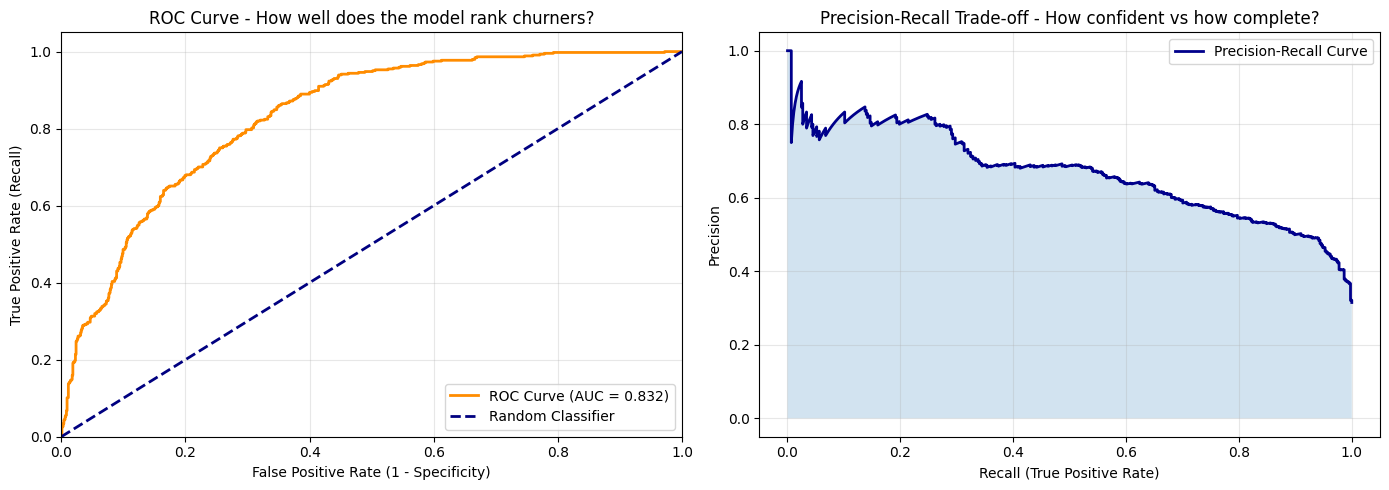

In [33]:
fpr,tpr,roc_thresholds=roc_curve(y_test,y_pred_proba)
roc_auc=auc(fpr,tpr)

precision,recall,pr_thresholds=precision_recall_curve(y_test,y_pred_proba)

fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve - How well does the model rank churners?')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall, precision, color='darkblue', lw=2, label='Precision-Recall Curve')
axes[1].fill_between(recall, precision, alpha=0.2)
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Trade-off - How confident vs how complete?')
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import precision_score,recall_score, f1_score
print("THRESHOLD ANALYSIS:")

thresholds_to_test=[0.3, 0.4,0.5,0.6]
results=[]

print("\nTesting thresholds\n")

for threshold in thresholds_to_test:
    y_pred_custom=(y_pred_proba>=threshold).astype(int)

    precision=precision_score(y_test,y_pred_custom,zero_division=0)
    recall=recall_score(y_test,y_pred_custom,zero_division=0)
    f1=f1_score(y_test,y_pred_custom,zero_division=0)
    nums_predicted_churn=(y_pred_custom==1).sum()

    results.append({
        'threshold':threshold,
        'precision':precision,
        'recall':recall,
        'f1_score':f1,
        'predicted_churners':nums_predicted_churn
    })

    print(f"Threshold: {threshold}")
    print(f"Customers predicted to churn : {nums_predicted_churn:,}")
    print(f"Precision(confidence in predictions): {precision:.3f}")
    print(f"Recall (catch rate): {recall:.3f}")
    print(f"F1 score (balance): {f1:.3f}")
    print()

THRESHOLD ANALYSIS:

Testing thresholds

Threshold: 0.3
Customers predicted to churn : 624
Precision(confidence in predictions): 0.556
Recall (catch rate): 0.782
F1 score (balance): 0.650

Threshold: 0.4
Customers predicted to churn : 469
Precision(confidence in predictions): 0.620
Recall (catch rate): 0.655
F1 score (balance): 0.637

Threshold: 0.5
Customers predicted to churn : 347
Precision(confidence in predictions): 0.683
Recall (catch rate): 0.534
F1 score (balance): 0.599

Threshold: 0.6
Customers predicted to churn : 237
Precision(confidence in predictions): 0.688
Recall (catch rate): 0.367
F1 score (balance): 0.479

